
═══════════════════════════════════════════════════════
   EMPLOYEE ATTRITION — LOGISTIC REGRESSION PIPELINE
═══════════════════════════════════════════════════════

✅ Dataset loaded  →  5,000 rows × 17 columns
   Columns : ['EmployeeID', 'Age', 'YearsAtCompany', 'Salary', 'OvertimeHours', 'JobSatisfaction', 'PerformanceScore', 'PromotionCount', 'CommuteTime', 'TrainingHours', 'PeerRating', 'ManagerRating', 'ProjectsCompleted', 'RemoteDaysPerWeek', 'WorkLifeBalance', 'Absences', 'Attrition']

✅ No missing values found in feature columns.

📊 Target distribution:
   Stays (0) : 4,841
   Leaves (1): 159

✅ Features standardised with StandardScaler.

✅ Data split  →  Train: 4,000  |  Test: 1,000

✅ Logistic Regression model trained successfully.

═════════════════════════════════════════════
        MODEL EVALUATION RESULTS
═════════════════════════════════════════════
  Accuracy  : 0.9680  (96.80 %)
  Precision : 0.0000
  Recall    : 0.0000
  F1 Score  : 0.0000
  ROC-AUC   : 0.8423
═════

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


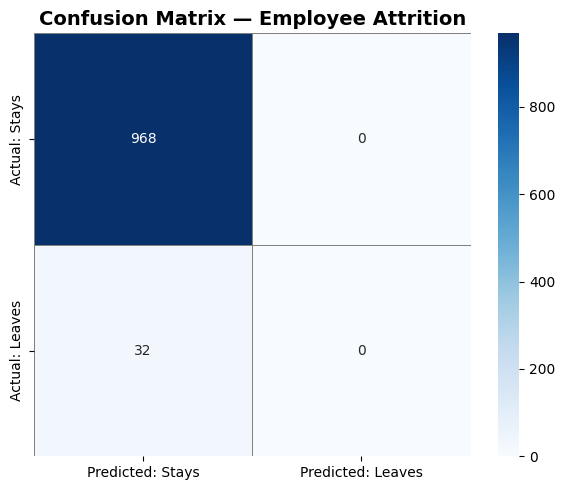

✅ Confusion matrix saved → confusion_matrix.png


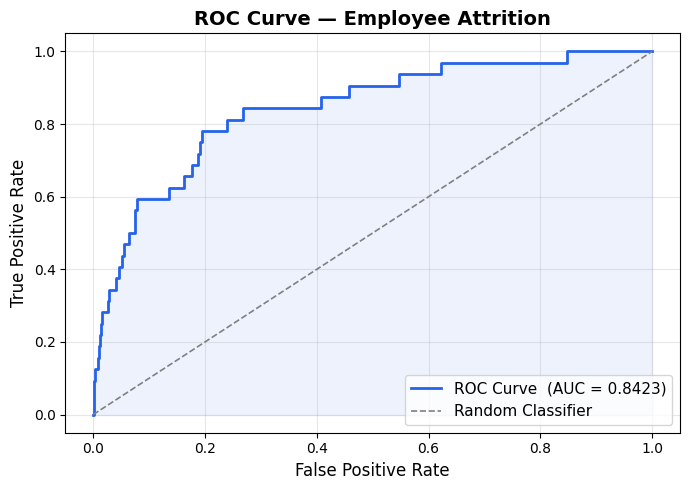

✅ ROC curve saved → roc_curve.png

📈 Feature Coefficients (influence on attrition):
          Feature  Coefficient
    OvertimeHours     0.878761
      CommuteTime     0.525847
              Age     0.180243
       PeerRating     0.157820
 PerformanceScore     0.131018
         Absences     0.027059
           Salary     0.019660
   PromotionCount    -0.012547
    ManagerRating    -0.047415
RemoteDaysPerWeek    -0.068178
ProjectsCompleted    -0.074189
    TrainingHours    -0.116679
   YearsAtCompany    -0.338561
  JobSatisfaction    -0.580444
  WorkLifeBalance    -0.591037


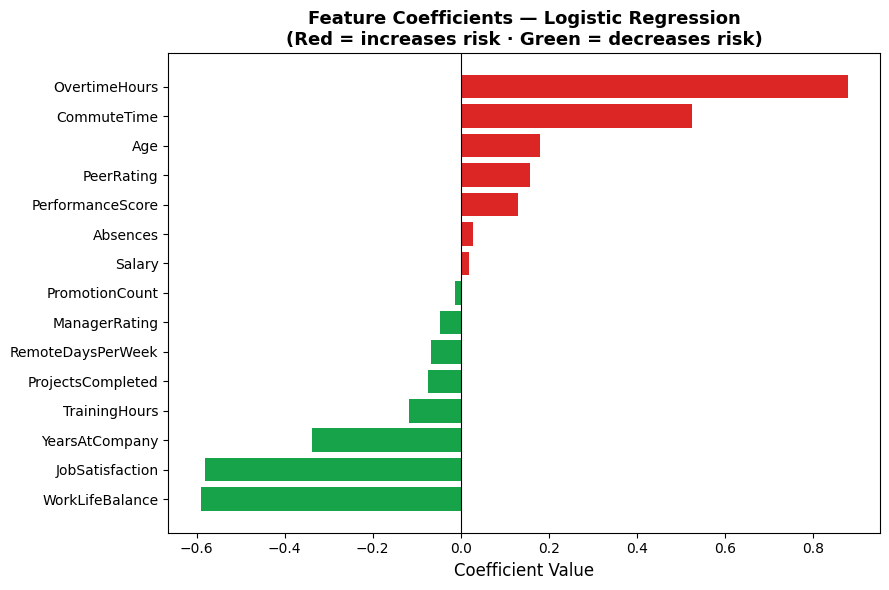

✅ Feature coefficients chart saved → feature_coefficients.png

✅ Model  saved → employee_attrition_logistic_model.pkl
✅ Scaler saved → employee_attrition_scaler.pkl

───────────────────────────────────────────────────────
  DEMO — predict_employee_attrition()
───────────────────────────────────────────────────────

┌─ Attrition Prediction ─────────────────────┐
│  Predicted class        : 0  (Stays ✅)
│  Attrition probability  : 0.0107  (1.1 %)
└────────────────────────────────────────────┘

  Return value: {'predicted_class': 0, 'attrition_label': 'Stays ✅', 'attrition_probability': 0.0107}

✅ Pipeline complete.



In [1]:
"""
============================================================
  Employee Attrition Prediction — Logistic Regression
============================================================
Author  : ML Engineer
Purpose : Train and evaluate a Logistic Regression model
          to predict whether an employee will leave (Attrition).
Dataset : employee_attrition_dataset_unique_5000.csv
============================================================
"""

# ─────────────────────────────────────────────────────────────
# 1. IMPORTS
# ─────────────────────────────────────────────────────────────
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.linear_model   import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing  import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    roc_curve,
    classification_report,
)

# ─────────────────────────────────────────────────────────────
# CONSTANTS
# ─────────────────────────────────────────────────────────────
DATA_PATH   = "employee_attrition_dataset_unique_5000.csv"
MODEL_PATH  = "employee_attrition_logistic_model.pkl"
SCALER_PATH = "employee_attrition_scaler.pkl"          # needed for inference
TARGET_COL  = "Attrition"
DROP_COLS   = ["EmployeeID"]                            # identifiers, not features
RANDOM_STATE = 42
TEST_SIZE    = 0.20

FEATURE_COLS = [
    "Age", "YearsAtCompany", "Salary", "OvertimeHours",
    "JobSatisfaction", "PerformanceScore", "PromotionCount",
    "CommuteTime", "TrainingHours", "PeerRating", "ManagerRating",
    "ProjectsCompleted", "RemoteDaysPerWeek", "WorkLifeBalance", "Absences",
]


# ═════════════════════════════════════════════════════════════
# STEP 2 — LOAD DATA
# ═════════════════════════════════════════════════════════════
def load_data(path: str) -> pd.DataFrame:
    """Load the CSV dataset and return a DataFrame."""
    if not os.path.exists(path):
        raise FileNotFoundError(
            f"Dataset not found at '{path}'. "
            "Please place the CSV in the same directory as this script."
        )
    df = pd.read_csv(path)
    print(f"\n✅ Dataset loaded  →  {df.shape[0]:,} rows × {df.shape[1]} columns")
    print(f"   Columns : {list(df.columns)}")
    return df


# ═════════════════════════════════════════════════════════════
# STEP 3 — PREPROCESSING
# ═════════════════════════════════════════════════════════════
def preprocess(df: pd.DataFrame):
    """
    Preprocess the raw DataFrame:
      • Drop identifier columns
      • Separate features (X) and target (y)
      • Report missing values
      • Standardise features with StandardScaler
    Returns: X_scaled (ndarray), y (Series), scaler, feature_names (list)
    """
    # ── 3a. Drop non-feature columns ─────────────────────────
    df = df.drop(columns=DROP_COLS, errors="ignore")

    # ── 3b. Separate X and y ─────────────────────────────────
    X = df[FEATURE_COLS].copy()
    y = df[TARGET_COL].copy()

    # ── 3c. Missing-value report ──────────────────────────────
    missing = X.isnull().sum()
    if missing.any():
        print("\n⚠️  Missing values detected — filling with column median:")
        print(missing[missing > 0])
        X = X.fillna(X.median())
    else:
        print("\n✅ No missing values found in feature columns.")

    # ── 3d. Class distribution ────────────────────────────────
    counts = y.value_counts()
    print(f"\n📊 Target distribution:\n"
          f"   Stays (0) : {counts.get(0, 0):,}\n"
          f"   Leaves (1): {counts.get(1, 0):,}")

    # ── 3e. Standardise features ──────────────────────────────
    scaler   = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    print("\n✅ Features standardised with StandardScaler.")

    return X_scaled, y, scaler, FEATURE_COLS


# ═════════════════════════════════════════════════════════════
# STEP 4 — TRAIN / TEST SPLIT
# ═════════════════════════════════════════════════════════════
def split_data(X, y):
    """Split into 80 % training / 20 % testing with a fixed random seed."""
    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=TEST_SIZE,
        random_state=RANDOM_STATE,
        stratify=y,          # preserve class ratio in both splits
    )
    print(f"\n✅ Data split  →  Train: {len(X_train):,}  |  Test: {len(X_test):,}")
    return X_train, X_test, y_train, y_test


# ═════════════════════════════════════════════════════════════
# STEP 5 — TRAIN MODEL
# ═════════════════════════════════════════════════════════════
def train_model(X_train, y_train) -> LogisticRegression:
    """Instantiate and fit a Logistic Regression classifier."""
    model = LogisticRegression(
        solver="lbfgs",
        max_iter=1000,
        random_state=RANDOM_STATE,
    )
    model.fit(X_train, y_train)
    print("\n✅ Logistic Regression model trained successfully.")
    return model


# ═════════════════════════════════════════════════════════════
# STEP 6 — EVALUATE MODEL
# ═════════════════════════════════════════════════════════════
def evaluate_model(model, X_test, y_test):
    """
    Compute and print:
      Accuracy · Precision · Recall · F1 · ROC-AUC
    Returns y_pred and y_prob for downstream plotting.
    """
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]   # probability of class 1

    acc  = accuracy_score (y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec  = recall_score   (y_test, y_pred, zero_division=0)
    f1   = f1_score       (y_test, y_pred, zero_division=0)
    auc  = roc_auc_score  (y_test, y_prob)

    print("\n" + "═" * 45)
    print("        MODEL EVALUATION RESULTS")
    print("═" * 45)
    print(f"  Accuracy  : {acc:.4f}  ({acc*100:.2f} %)")
    print(f"  Precision : {prec:.4f}")
    print(f"  Recall    : {rec:.4f}")
    print(f"  F1 Score  : {f1:.4f}")
    print(f"  ROC-AUC   : {auc:.4f}")
    print("═" * 45)
    print("\n📋 Full Classification Report:\n")
    print(classification_report(y_test, y_pred, target_names=["Stays", "Leaves"]))

    return y_pred, y_prob


# ═════════════════════════════════════════════════════════════
# STEP 7 — CONFUSION MATRIX
# ═════════════════════════════════════════════════════════════
def plot_confusion_matrix(y_test, y_pred):
    """Plot a seaborn heatmap of the confusion matrix."""
    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(6, 5))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["Predicted: Stays", "Predicted: Leaves"],
        yticklabels=["Actual: Stays",    "Actual: Leaves"],
        linewidths=0.5,
        linecolor="gray",
    )
    plt.title("Confusion Matrix — Employee Attrition", fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.savefig("confusion_matrix.png", dpi=150)
    plt.show()
    print("✅ Confusion matrix saved → confusion_matrix.png")


# ═════════════════════════════════════════════════════════════
# STEP 8 — ROC CURVE
# ═════════════════════════════════════════════════════════════
def plot_roc_curve(y_test, y_prob):
    """Plot the Receiver Operating Characteristic (ROC) curve."""
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)

    plt.figure(figsize=(7, 5))
    plt.plot(fpr, tpr, color="#2563EB", lw=2, label=f"ROC Curve  (AUC = {auc:.4f})")
    plt.plot([0, 1], [0, 1], color="gray", lw=1.2, linestyle="--", label="Random Classifier")
    plt.fill_between(fpr, tpr, alpha=0.08, color="#2563EB")
    plt.xlabel("False Positive Rate", fontsize=12)
    plt.ylabel("True Positive Rate",  fontsize=12)
    plt.title("ROC Curve — Employee Attrition", fontsize=14, fontweight="bold")
    plt.legend(loc="lower right", fontsize=11)
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig("roc_curve.png", dpi=150)
    plt.show()
    print("✅ ROC curve saved → roc_curve.png")


# ═════════════════════════════════════════════════════════════
# STEP 9 — FEATURE COEFFICIENTS
# ═════════════════════════════════════════════════════════════
def print_feature_coefficients(model, feature_names: list):
    """
    Print and plot the logistic regression coefficients.
    Positive coefficient → increases attrition risk.
    Negative coefficient → decreases attrition risk.
    """
    coef_df = (
        pd.DataFrame({"Feature": feature_names, "Coefficient": model.coef_[0]})
        .sort_values("Coefficient", ascending=False)
        .reset_index(drop=True)
    )

    print("\n📈 Feature Coefficients (influence on attrition):")
    print(coef_df.to_string(index=False))

    # Bar chart
    plt.figure(figsize=(9, 6))
    colours = ["#DC2626" if c > 0 else "#16A34A" for c in coef_df["Coefficient"]]
    plt.barh(coef_df["Feature"], coef_df["Coefficient"], color=colours)
    plt.axvline(0, color="black", linewidth=0.8)
    plt.xlabel("Coefficient Value", fontsize=12)
    plt.title("Feature Coefficients — Logistic Regression\n"
              "(Red = increases risk · Green = decreases risk)",
              fontsize=13, fontweight="bold")
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.savefig("feature_coefficients.png", dpi=150)
    plt.show()
    print("✅ Feature coefficients chart saved → feature_coefficients.png")

    return coef_df


# ═════════════════════════════════════════════════════════════
# STEP 10 — SAVE MODEL
# ═════════════════════════════════════════════════════════════
def save_model(model, scaler):
    """Persist the trained model and scaler to disk with joblib."""
    joblib.dump(model,  MODEL_PATH)
    joblib.dump(scaler, SCALER_PATH)
    print(f"\n✅ Model  saved → {MODEL_PATH}")
    print(f"✅ Scaler saved → {SCALER_PATH}")


# ═════════════════════════════════════════════════════════════
# STEP 11 — INFERENCE FUNCTION
# ═════════════════════════════════════════════════════════════
def predict_employee_attrition(employee_features: dict) -> dict:
    """
    Predict attrition for a single employee.

    Parameters
    ----------
    employee_features : dict
        Keys must match FEATURE_COLS exactly.
        Example:
            {
                "Age": 35,
                "YearsAtCompany": 5,
                "Salary": 62000,
                "OvertimeHours": 15,
                "JobSatisfaction": 3,
                "PerformanceScore": 4,
                "PromotionCount": 1,
                "CommuteTime": 45,
                "TrainingHours": 10,
                "PeerRating": 3,
                "ManagerRating": 4,
                "ProjectsCompleted": 6,
                "RemoteDaysPerWeek": 2,
                "WorkLifeBalance": 3,
                "Absences": 8,
            }

    Returns
    -------
    dict with keys:
        predicted_class   – 0 (stays) or 1 (leaves)
        attrition_label   – human-readable label
        attrition_probability – float, probability of leaving
    """
    # ── Load artefacts from disk ──────────────────────────────
    if not os.path.exists(MODEL_PATH) or not os.path.exists(SCALER_PATH):
        raise FileNotFoundError(
            "Trained model / scaler not found. "
            "Run the full training pipeline first."
        )

    model  = joblib.load(MODEL_PATH)
    scaler = joblib.load(SCALER_PATH)

    # ── Validate input keys ───────────────────────────────────
    missing_keys = [f for f in FEATURE_COLS if f not in employee_features]
    if missing_keys:
        raise ValueError(f"Missing feature(s) in input dict: {missing_keys}")

    # ── Build input array in the correct column order ─────────
    values   = [[employee_features[f] for f in FEATURE_COLS]]
    X_input  = pd.DataFrame(values, columns=FEATURE_COLS)
    X_scaled = scaler.transform(X_input)

    # ── Predict ───────────────────────────────────────────────
    pred_class = int(model.predict(X_scaled)[0])
    pred_prob  = float(model.predict_proba(X_scaled)[0][1])

    label = "Leaves ⚠️" if pred_class == 1 else "Stays ✅"

    print(f"\n┌─ Attrition Prediction ─────────────────────┐")
    print(f"│  Predicted class        : {pred_class}  ({label})")
    print(f"│  Attrition probability  : {pred_prob:.4f}  ({pred_prob*100:.1f} %)")
    print(f"└────────────────────────────────────────────┘")

    return {
        "predicted_class":        pred_class,
        "attrition_label":        label,
        "attrition_probability":  round(pred_prob, 4),
    }


# ═════════════════════════════════════════════════════════════
# MAIN PIPELINE
# ═════════════════════════════════════════════════════════════
def main():
    print("\n" + "═" * 55)
    print("   EMPLOYEE ATTRITION — LOGISTIC REGRESSION PIPELINE")
    print("═" * 55)

    # 2. Load
    df = load_data(DATA_PATH)

    # 3. Preprocess
    X, y, scaler, feature_names = preprocess(df)

    # 4. Split
    X_train, X_test, y_train, y_test = split_data(X, y)

    # 5. Train
    model = train_model(X_train, y_train)

    # 6. Evaluate
    y_pred, y_prob = evaluate_model(model, X_test, y_test)

    # 7. Confusion matrix
    plot_confusion_matrix(y_test, y_pred)

    # 8. ROC curve
    plot_roc_curve(y_test, y_prob)

    # 9. Feature coefficients
    print_feature_coefficients(model, feature_names)

    # 10. Save model & scaler
    save_model(model, scaler)

    # 11. Demo inference
    print("\n" + "─" * 55)
    print("  DEMO — predict_employee_attrition()")
    print("─" * 55)
    sample_employee = {
        "Age":               35,
        "YearsAtCompany":     5,
        "Salary":         62000,
        "OvertimeHours":     15,
        "JobSatisfaction":    3,
        "PerformanceScore":   4,
        "PromotionCount":     1,
        "CommuteTime":       45,
        "TrainingHours":     10,
        "PeerRating":         3,
        "ManagerRating":      4,
        "ProjectsCompleted":  6,
        "RemoteDaysPerWeek":  2,
        "WorkLifeBalance":    3,
        "Absences":           8,
    }
    result = predict_employee_attrition(sample_employee)
    print(f"\n  Return value: {result}")

    print("\n✅ Pipeline complete.\n")


# ─────────────────────────────────────────────────────────────
if __name__ == "__main__":
    main()